# Figure 1 — Spatial diversity of amenities and travellers across U.S. urban areas

This notebook reproduces the four panels of **Figure 1**:

| Panel | Content |
|-------|---------|
| **1A** | Amenity-mix diversity (entropy $H$) per urban area, by amenity category |
| **1B** | Traveller diversity (entropy $H$) per urban area, by demographic group |
| **1C** | Distribution of amenity entropy for New York (KDE, per category) |
| **1D** | Distribution of traveller entropy for New York (KDE, per group) |

### Inputs
All read from `dataindir` (`server_done_5/` by default):

- `1_spatial_charac_amenities.csv` — per-simulation amenity entropy
- `1_spatial_charac_people.csv` — per-simulation traveller entropy
- `n_zones_cities.csv` — number of zones per metro area

### Outputs
SVG figures written to `figoutdir` (`figures/`).

### Dependencies
`numpy`, `pandas`, `scipy`, `matplotlib`, `seaborn`

```bash
pip install numpy pandas scipy matplotlib seaborn
```

> Adjust `dataindir` / `figoutdir` in the setup cell to match your paths.

## Setup

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patheffects as path_effects
import seaborn as sns

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# --- global matplotlib style ---
mpl.rcParams['figure.figsize'] = (10, 10)
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['mathtext.rm'] = 'serif'

print('Libraries loaded!')

Libraries loaded!


In [2]:
colors = {
    'non married' : '#D55E00', 
    'married' : '#0072b2',
    
    'parent' : '#009E73',
    'non parent' : '#E69F00',
    
    'all' : '#000000',

    'residential' : '#F9C80E', # tab:blue : #1f77b4
    'transport' : '#F99719', # tab:orange : #ff7f0e
    'health' : '#F86624', # tab:green : #2ca02c
    'work' : '#F14E35', # tab:red : #d62728
    'education' : '#EA3546', # tab:purple : #9467bd
    'religious' : '#A83271', # tab:brown : #8c564b
    'leisure' : '#662E9B', # tab:pink : #e377c2
    'food' : '#5575B4', # tab:olive : #bcbd22
    'services' : '#43BCCD', # tab:cyan : #17becf

}

# graphics settings amenities

label_iter_am = ['residential', 'leisure', 'services', 'health', 'food',\
              'transport', 'work', 'education', 'religious', 'all']

label_marker_am = ['o', '>', 'D', '^', 'v',\
              'p', 'H', '*', 'P', 's']

label_color_am = ['silver', 'silver', 'silver', 'silver', 'silver',\
              'silver', 'silver', 'silver', 'silver', 'firebrick']

# graphics settings people

label_iter_pe = ['non parent', 'parent', 'non married', 'married', 'all']

label_marker_pe = ['o', 'P', '^', 'H', 's']

label_color_pe = ['silver', 'silver', 'silver', 'silver', 'firebrick']


print('Common variables set!')

Common variables set!


In [3]:
# Input directory holding the pre-computed CSVs, and output directory for figures.
dataindir = 'server_done_5/'
figoutdir = 'figures/'

Path(figoutdir).mkdir(parents=True, exist_ok=True)
print(f'Reading data from: {dataindir}')
print(f'Saving figures to: {figoutdir}')

## 1. Load data

In [4]:
usa_charac_amenities = pd.read_csv(dataindir + "1_spatial_charac_amenities.csv")
usa_charac_amenities.columns = ['MET2013_LABEL', 'group', 'label', 'sim', 'entropy']
usa_charac_amenities = usa_charac_amenities.merge(pd.read_csv(dataindir + "n_zones_cities.csv"))
usa_charac_amenities['label'] = usa_charac_amenities['label'].str.lower()

# Short "ZONE_LABEL": leading city name + number of zones, e.g. "New York (23)".
usa_charac_amenities['ZONE_LABEL'] = usa_charac_amenities['MET2013_LABEL'].str.split(",", expand=True)[0]
usa_charac_amenities['ZONE_LABEL'] = usa_charac_amenities['ZONE_LABEL'].str.split("-", expand=True)[0]
usa_charac_amenities['ZONE_LABEL'] = usa_charac_amenities.apply(
    lambda r: f"{r['ZONE_LABEL']} ({r['n_zones']})", axis=1)

usa_charac_amenities.head()

,MET2013_LABEL,group,label,sim,entropy,n_zones,ZONE_LABEL
0,"Minneapolis-St. Paul-Bloomington, MN-WI",categories,all,0,0.375168,10,Minneapolis (10)
1,"Minneapolis-St. Paul-Bloomington, MN-WI",categories,all,1,0.375082,10,Minneapolis (10)
2,"Minneapolis-St. Paul-Bloomington, MN-WI",categories,all,2,0.375248,10,Minneapolis (10)
3,"Minneapolis-St. Paul-Bloomington, MN-WI",categories,all,3,0.375228,10,Minneapolis (10)
4,"Minneapolis-St. Paul-Bloomington, MN-WI",categories,all,4,0.375205,10,Minneapolis (10)


In [5]:
usa_charac_people = pd.read_csv(dataindir + "1_spatial_charac_people.csv")
usa_charac_people.columns = ['percentage', 'MET2013_LABEL', 'group', 'label', 'sim', 'entropy']
usa_charac_people = usa_charac_people.merge(pd.read_csv(dataindir + "n_zones_cities.csv"))
usa_charac_people['label'] = usa_charac_people['label'].str.lower()

usa_charac_people['ZONE_LABEL'] = usa_charac_people['MET2013_LABEL'].str.split(",", expand=True)[0]
usa_charac_people['ZONE_LABEL'] = usa_charac_people['ZONE_LABEL'].str.split("-", expand=True)[0]
usa_charac_people['ZONE_LABEL'] = usa_charac_people.apply(
    lambda r: f"{r['ZONE_LABEL']} ({r['n_zones']})", axis=1)

usa_charac_people.head()

,percentage,MET2013_LABEL,group,label,sim,entropy,n_zones,ZONE_LABEL
0,0.8,"Minneapolis-St. Paul-Bloomington, MN-WI",WITH_CHILDREN,no children,0,0.833174,10,Minneapolis (10)
1,0.8,"Minneapolis-St. Paul-Bloomington, MN-WI",WITH_CHILDREN,no children,1,0.832608,10,Minneapolis (10)
2,0.8,"Minneapolis-St. Paul-Bloomington, MN-WI",WITH_CHILDREN,no children,2,0.833018,10,Minneapolis (10)
3,0.8,"Minneapolis-St. Paul-Bloomington, MN-WI",WITH_CHILDREN,no children,3,0.833364,10,Minneapolis (10)
4,0.8,"Minneapolis-St. Paul-Bloomington, MN-WI",WITH_CHILDREN,no children,4,0.832696,10,Minneapolis (10)


### (Optional) convergence check

Quick diagnostic: mean entropy per area as the number of sampled simulations grows.
Flat curves indicate the estimates have converged. Skip if you only want the figures.

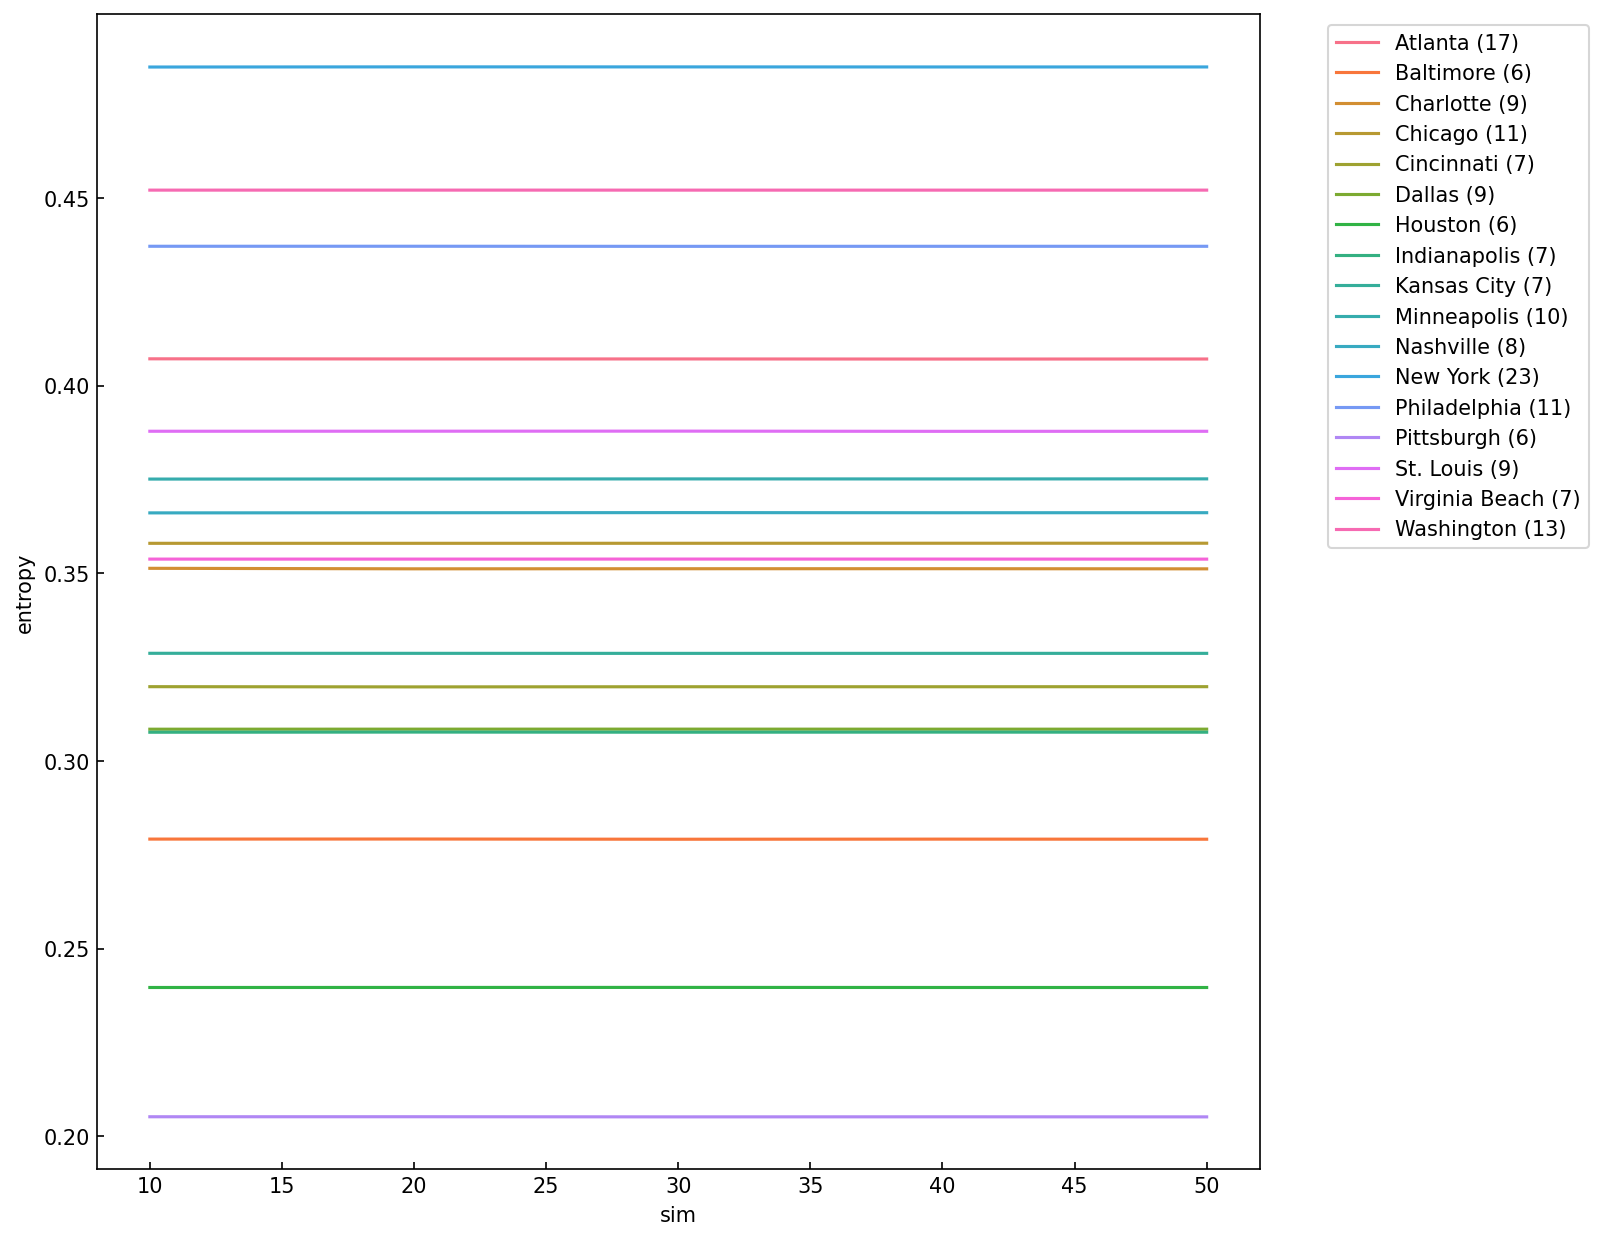

In [6]:
sat_ = pd.DataFrame(columns=['ZONE_LABEL','entropy','sim'])
for x in [10,20,30,40, 50]:

    simulations = np.random.choice(usa_charac_amenities['sim'].unique(), x)
    mean_x = usa_charac_amenities[(usa_charac_amenities['label']=='all') & (usa_charac_amenities['sim'].isin(simulations))].groupby('ZONE_LABEL')['entropy'].mean().reset_index()
    mean_x['sim'] = x
    sat_ = pd.concat([sat_,mean_x])

plt.figure(dpi=150)
sns.lineplot(data=sat_, x='sim', y='entropy', hue='ZONE_LABEL')
plt.legend(bbox_to_anchor=(1.05, 1.))

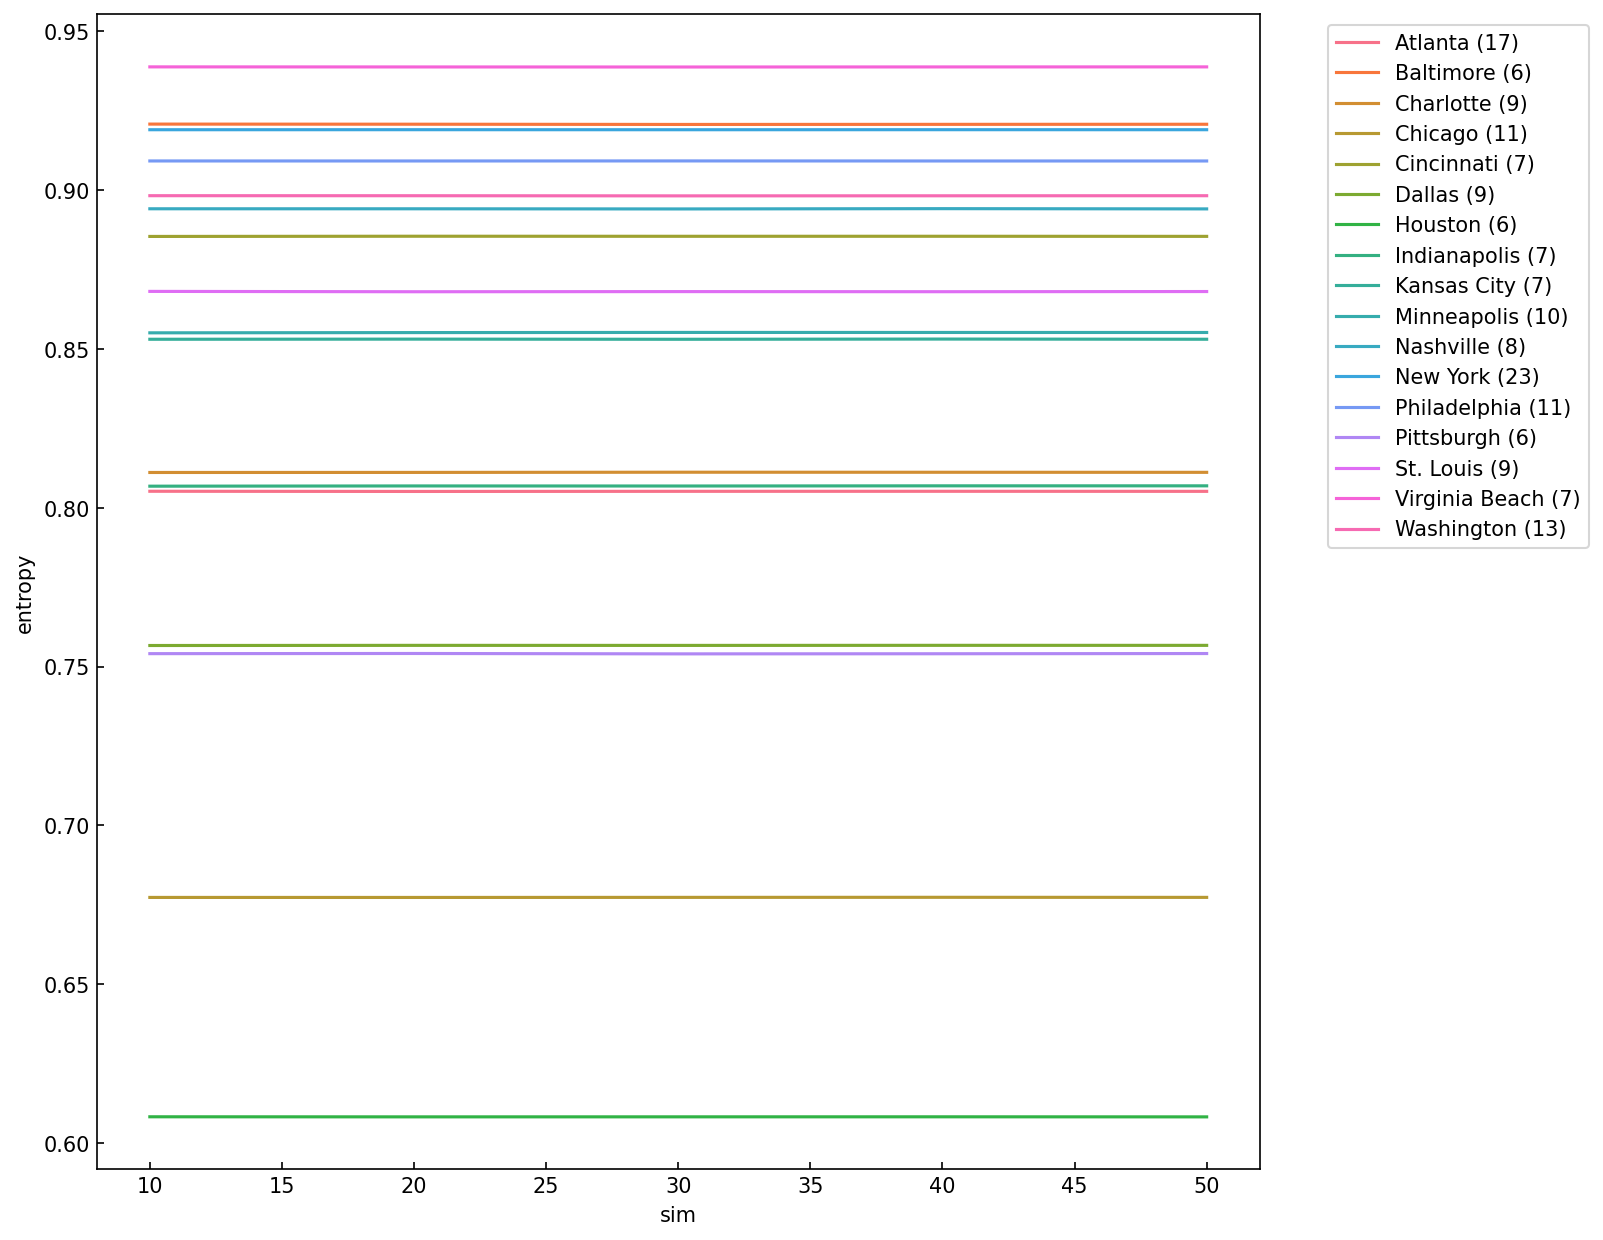

In [7]:
sat_ = pd.DataFrame(columns=['ZONE_LABEL','entropy','sim'])
for x in [10,20,30,40, 50]:

    simulations = np.random.choice(usa_charac_people['sim'].unique(), x)
    mean_x = usa_charac_people[(usa_charac_people['label']=='all') & (usa_charac_people['sim'].isin(simulations))].groupby('ZONE_LABEL')['entropy'].mean().reset_index()
    mean_x['sim'] = x
    sat_ = pd.concat([sat_,mean_x])

plt.figure(dpi=150)
sns.lineplot(data=sat_, x='sim', y='entropy', hue='ZONE_LABEL')
plt.legend(bbox_to_anchor=(1.05, 1.))

## 2. Ordering of urban areas\n\n`label_zones` orders metros by number of zones; reused as the x-axis in panels 1A and 1B.

In [8]:
ordered_zones = usa_charac_people[['n_zones','ZONE_LABEL']].drop_duplicates().sort_values(by=['n_zones','ZONE_LABEL']).reset_index()[['n_zones','ZONE_LABEL']].reset_index()
ordered_zones.columns = ['ordered','n_zones','ZONE_LABEL']
label_zones = ordered_zones.sort_values(by=['ordered'])['ZONE_LABEL'].unique()
label_zones

array(['Baltimore (6)', 'Houston (6)', 'Pittsburgh (6)', 'Cincinnati (7)',
       'Indianapolis (7)', 'Kansas City (7)', 'Virginia Beach (7)',
       'Nashville (8)', 'Charlotte (9)', 'Dallas (9)', 'St. Louis (9)',
       'Minneapolis (10)', 'Chicago (11)', 'Philadelphia (11)',
       'Washington (13)', 'Atlanta (17)', 'New York (23)'], dtype=object)

## Fig. 1A — Amenity diversity across urban areas

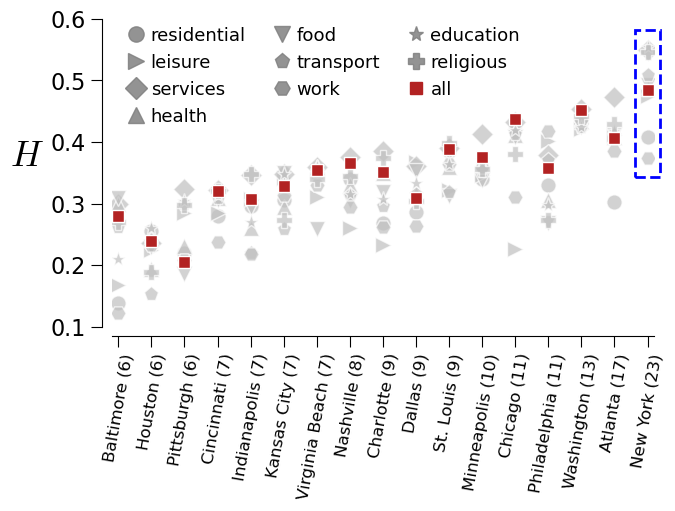

In [9]:
# names of the urban areas

# label_zones = usa_charac_amenities[['n_zones','ZONE_LABEL']]\
#               .sort_values(by='n_zones')['ZONE_LABEL'].unique()


# values of the x variable

valx = np.arange(len(label_zones))

valxt = np.arange(len(label_zones))
valxt[0] -= 0.2
valxt[-1] += 0.2

# extracting data on y variable
mydata = usa_charac_amenities.groupby(['n_zones','label','ZONE_LABEL'])\
         ['entropy'].mean().reset_index().sort_values(by='n_zones').dropna()


# creating the figure

fig, ax = plt.subplots(figsize=(7,4))


# iterating over the data types except for the last (ALL)
for il in range(len(label_iter_am[:-1])):
    l = label_iter_am[il]
    m = label_marker_am[il]
    c = label_color_am[il]
    
    valy = mydata.loc[mydata['label'] == l]['entropy']

    plt.plot(valx, valy, markersize=11, label = l,\
                 marker=m,  markeredgecolor='w',ls='None',\
                 color=c, zorder=1, alpha=0.7)


# iterating over the last case (ALL)    
    
m = label_marker_am[-1]        
l = label_iter_am[-1]
c = label_color_am[-1]

valy = mydata.loc[mydata['label'] == l]['entropy']

plt.plot(valx, valy, markersize=9, label = l,\
             marker=m, markeredgecolor='w',ls='None',\
             color=c, zorder=3, alpha=1)


# rectangle around NY case
rect = ax.add_patch(Rectangle((15.625, 0.3425), 0.75, 0.24,
                        edgecolor = 'blue',
                        linestyle = '--',
                        fill=False, clip_on=False,
                        lw=2, zorder=2))


# legend
leg = plt.legend(ncol=3, frameon=False, fontsize=13,\
                 handlelength=0, bbox_to_anchor=(0.05,0.4), loc='lower left',\
                 bbox_transform=ax.transData)

for k in range(len(leg.legend_handles)-1):
    legobj = leg.legend_handles[k]
    legobj.set_color('grey')
    legobj.set_alpha(0.85)
    legobj.set_markeredgecolor(None)

legobj = leg.legend_handles[-1]
legobj.set_color('firebrick')
legobj.set_alpha(1)
legobj.set_markeredgecolor(None)
    
    
# spines & etc.

ax.spines[['right', 'top']].set_visible(False)

ax.spines.left.set_position(('data', -0.5))
ax.spines.bottom.set_position(('data', 0.085))


# ticks
ax.set_xticks(valxt)
ax.tick_params(axis='both', which='major',length=8, direction='out')
ax.tick_params(axis='x', which='major', labelsize=12)
ax.tick_params(axis='y', which='major', labelsize=16)
ax.set_xticklabels(label_zones, rotation=80, ha='center')

plt.ylim(0.1,0.6)
plt.xlim(-0.2,16.2)

plt.ylabel(r"$H$", fontsize=26, rotation='horizontal', labelpad=17)

ax.set_clip_on(False)

# saving figure

plt.savefig(figoutdir+'entropy-amenities-all_areas.svg', bbox_inches='tight')

plt.show()

## Fig. 1B — Traveller diversity across urban areas\n\nFirst normalise the demographic labels, then attach the ordering used on the x-axis.

In [10]:
# Normalise the demographic labels used in legends and plots.
usa_charac_people.label.replace('no children', 'non parent', inplace=True)
usa_charac_people.label.replace('with children', 'parent', inplace=True)
usa_charac_people.label.replace('not married', 'non married', inplace=True)

print('Label updated!')

Label updated!


In [11]:
usa_charac_people = usa_charac_people.merge(ordered_zones)

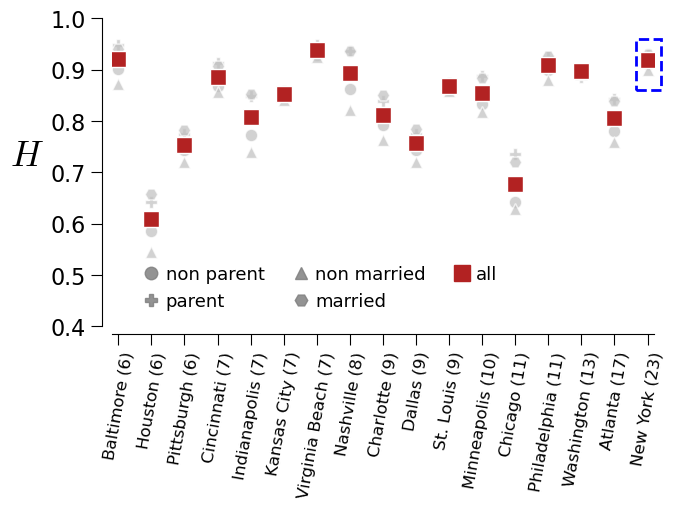

In [12]:
# names of the urban areas

# values of the x variable

valx = np.arange(len(label_zones))

valxt = np.arange(len(label_zones))
valxt[0] -= 0.2
valxt[-1] += 0.2

# extracting data on y variable
mydata = usa_charac_people.sort_values(by='ordered').groupby(['ordered','n_zones','label','ZONE_LABEL'])\
         ['entropy'].mean().reset_index().sort_values(by='ordered').dropna()


# creating the figure

fig, ax = plt.subplots(figsize=(7,4))


# iterating over the data types except for the last (ALL)
for il in range(len(label_iter_pe[:-1])):
    l = label_iter_pe[il]
    m = label_marker_pe[il]
    c = label_color_pe[il]
    
    valy = mydata.loc[mydata['label'] == l]['entropy']

    plt.plot(valx, valy, markersize=9, label = l,\
                 marker=m, lw = 1.25, ls='None', markeredgecolor='w',\
                 color=c, zorder=1, alpha=0.7)


# iterating over the last case (ALL)    
    
m = label_marker_pe[-1]        
l = label_iter_pe[-1]
c = label_color_pe[-1]

valy = mydata.loc[mydata['label'] == l]['entropy']

plt.plot(valx, valy, markersize=11, label = l,\
             marker=m, lw = 2.5, ls = 'None', markeredgecolor='w',\
             color=c, zorder=3, alpha=1)



# rectangle around NY case
rect = ax.add_patch(Rectangle((15.65, 0.86), 0.75, 0.10,
                        edgecolor = 'blue',
                        linestyle= '--', 
                        fill=False, clip_on=False,
                        lw=2, zorder=2))


# legend
leg = plt.legend(ncol=3, frameon=False, fontsize=13,\
                 handlelength=0, bbox_to_anchor=(0.5,0.4), loc='lower left',\
                 bbox_transform=ax.transData)

for k in range(len(leg.legend_handles)-1):
    legobj = leg.legend_handles[k]
    legobj.set_color('grey')
    legobj.set_alpha(0.85)
    legobj.set_markeredgecolor(None)

legobj = leg.legend_handles[-1]
legobj.set_color('firebrick')
legobj.set_alpha(1)
legobj.set_markeredgecolor(None)
    
    
# spines
ax.spines[['right', 'top']].set_visible(False)
ax.spines.left.set_position(('data', -0.5))
ax.spines.bottom.set_position(('data', 0.385))

# ticks
ax.set_xticks(valxt)
ax.tick_params(axis='both', which='major',length=8, direction='out')
ax.tick_params(axis='x', which='major', labelsize=12)
ax.tick_params(axis='y', which='major', labelsize=16)
ax.set_xticklabels(label_zones, rotation=80, ha='center')

plt.ylim(0.4,1.0)
plt.xlim(-0.2,16.2)

plt.ylabel(r"$H$", fontsize=26, rotation='horizontal', labelpad=17)

# saving figure
ax.set_clip_on(False)

plt.savefig(figoutdir+'entropy-travellers-all_areas.svg', bbox_inches='tight')

plt.show()

## Fig. 1C — New York: amenity entropy distributions (KDE)

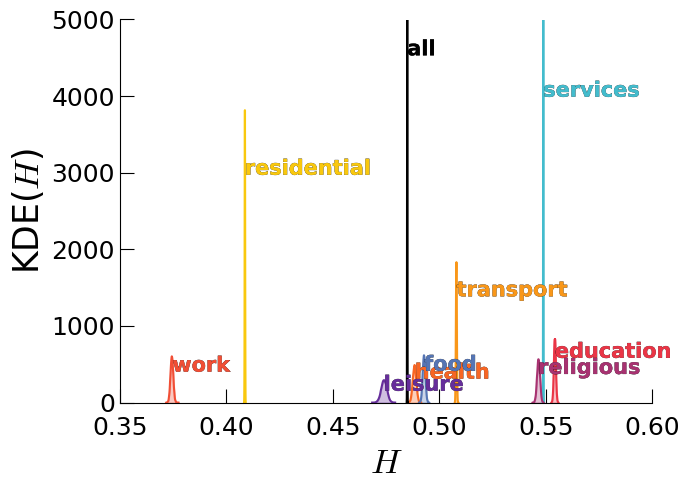

In [13]:
fig, ax = plt.subplots(figsize=(7,5))

mycity = 'New York (23)'
nr_points_sample = 100

for label2 in label_iter_am:
    p1 = usa_charac_amenities[(usa_charac_amenities['ZONE_LABEL'] == mycity) & 
            (usa_charac_amenities['label'] == label2) ]['entropy']
    
    min_p1 = min(p1)
    max_p1 = max(p1)
    
    vx1 = np.linspace(min_p1, max_p1, nr_points_sample)
    xdiff = vx1[1]-vx1[0]
    
    kde_p1 = st.gaussian_kde(p1)
    vy1 = np.reshape(kde_p1(vx1).T, nr_points_sample)
    
    if vy1[0] != 0:
        vy1 = np.insert(vy1, 0, 0.)
        vx1 = np.insert(vx1, 0, vx1[0]-xdiff)
    
    if vy1[-1] != 0:
        vy1 = np.append(vy1, 0.)
        vx1 = np.append(vx1, vx1[-1]+xdiff)
    
    # plot
    plt.plot(vx1, vy1, color = colors[label2], zorder=2, alpha=1)
    # curve filling
    plt.fill_between(vx1, vy1, color = colors[label2], zorder=1, alpha=0.3)
    
    # text close to peak
    tposx = np.mean(vx1)
    tposy = 0.8*np.max(vy1)
    
    mytext = ax.text(tposx, tposy, label2, fontsize=15, zorder=3,\
                     fontweight="bold", color=colors[label2],\
                     ha="left", va="center", transform=ax.transData)
    
    mytext.set_path_effects([path_effects.Stroke(linewidth=0.25, foreground='black'),
                       path_effects.Normal()])

plt.xlabel(r"$H$", fontsize=25)
plt.ylabel(r"KDE($H$)", fontsize=25)

plt.xlim([0.35,0.6])
plt.ylim([0,5000])
           
ax.tick_params(axis='both',which='major',length=10, labelsize=18)
ax.tick_params(axis='x',which='major', pad=10)
           
ax.spines[['right', 'top']].set_visible(False)     

# saving figure
plt.tight_layout()
plt.savefig(figoutdir+'kde_entropy-amenities-ny_areas.svg', bbox_inches='tight')

plt.show()

## Fig. 1D — New York: traveller entropy distributions (KDE)

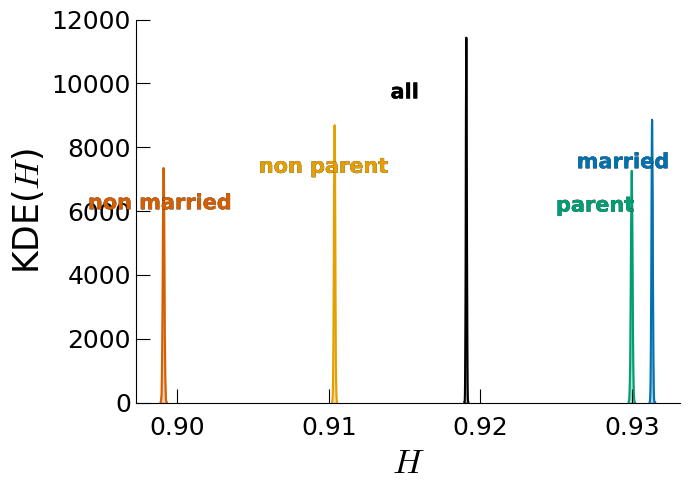

In [14]:
fig, ax = plt.subplots(figsize=(7,5))
mycity = 'New York (23)'
nr_points_sample = 100

for label2 in label_iter_pe:
    p1 = usa_charac_people[(usa_charac_people['ZONE_LABEL'] == mycity) & 
            (usa_charac_people['label'] == label2) ]['entropy']

    min_p1 = min(p1)
    max_p1 = max(p1)
    
    vx1 = np.linspace(min_p1, max_p1, nr_points_sample)
    xdiff = vx1[1]-vx1[0]
    
    kde_p1 = st.gaussian_kde(p1)
    vy1 = np.reshape(kde_p1(vx1).T, nr_points_sample)
    
    if vy1[0] != 0:
        vy1 = np.insert(vy1, 0, 0.)
        vx1 = np.insert(vx1, 0, vx1[0]-xdiff)
    
    if vy1[-1] != 0:
        vy1 = np.append(vy1, 0.)
        vx1 = np.append(vx1, vx1[-1]+xdiff)
    
    # plot
    plt.plot(vx1, vy1, color = colors[label2], zorder=2, alpha=1)
    # curve filling
    plt.fill_between(vx1, vy1, color = colors[label2], zorder=1, alpha=0.3)
    
    # text close to peak
    tposx = np.mean(vx1)-0.005
    tposy = 0.85*np.max(vy1)
    
    mytext = ax.text(tposx, tposy, label2, fontsize=15, zorder=3,\
                     fontweight="bold", color=colors[label2],\
                     ha="left", va="center", transform=ax.transData)
    
    mytext.set_path_effects([path_effects.Stroke(linewidth=0.25, foreground='black'),
                       path_effects.Normal()])

plt.xlabel(r"$H$", fontsize=25)
plt.ylabel(r"KDE($H$)", fontsize=25)

ax.tick_params(axis='both',which='major',length=10, labelsize=18)
ax.tick_params(axis='x',which='major', pad=10)
plt.ylim(0,12000)

ax.spines[['right', 'top']].set_visible(False)     

# saving figure
plt.tight_layout()
plt.savefig(figoutdir+'kde_entropy-travellers-ny_areas.svg', bbox_inches='tight')

plt.show()